<a href="https://colab.research.google.com/github/pxu/Generative_Deep_Learning_2nd_Edition/blob/main/notebooks/06_normflow/01_realnvp/realnvp_assignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌀 RealNVP

In this notebook, we'll walk through the steps required to train your own RealNVP network to predict the distribution of a demo dataset

The code has been adapted from the excellent [RealNVP tutorial](https://keras.io/examples/generative/real_nvp) created by Mandolini Giorgio Maria, Sanna Daniele and Zannini Quirini Giorgio available on the Keras website.

In [47]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets

import tensorflow as tf
from tensorflow.keras import (
    layers,
    models,
    regularizers,
    metrics,
    optimizers,
    callbacks,
)
#import tensorflow_probability as tfp

## 0. Parameters <a name="parameters"></a>

In [56]:
COUPLING_DIM = 256
COUPLING_LAYERS = 2
INPUT_DIM = 2
REGULARIZATION = 0.01
BATCH_SIZE = 256
#EPOCHS = 300
EPOCHS = 60

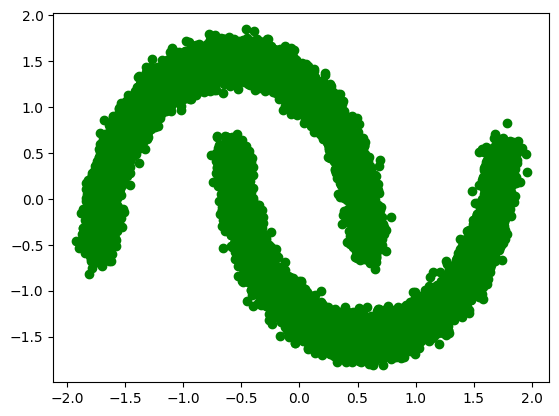

In [49]:
# Load the data
data = datasets.make_moons(30000, noise=0.05)[0].astype("float32")
norm = layers.Normalization()
norm.adapt(data)
normalized_data = norm(data)
plt.scatter(
    normalized_data.numpy()[:, 0], normalized_data.numpy()[:, 1], c="green"
)
plt.show()

## 2. Build the RealNVP network <a name="build"></a>

In [50]:
def Coupling(input_dim, coupling_dim, reg):
    input_layer = layers.Input(shape=input_dim)

    s_layer_1 = layers.Dense(
        coupling_dim, activation="relu", kernel_regularizer=regularizers.l2(reg)
    )(input_layer)
    s_layer_2 = layers.Dense(
        coupling_dim, activation="relu", kernel_regularizer=regularizers.l2(reg)
    )(s_layer_1)
    s_layer_3 = layers.Dense(
        coupling_dim, activation="relu", kernel_regularizer=regularizers.l2(reg)
    )(s_layer_2)
    s_layer_4 = layers.Dense(
        coupling_dim, activation="relu", kernel_regularizer=regularizers.l2(reg)
    )(s_layer_3)
    s_layer_5 = layers.Dense(
        input_dim[0], activation="tanh", kernel_regularizer=regularizers.l2(reg)
    )(s_layer_4)

    t_layer_1 = layers.Dense(
        coupling_dim, activation="relu", kernel_regularizer=regularizers.l2(reg)
    )(input_layer)
    t_layer_2 = layers.Dense(
        coupling_dim, activation="relu", kernel_regularizer=regularizers.l2(reg)
    )(t_layer_1)
    t_layer_3 = layers.Dense(
        coupling_dim, activation="relu", kernel_regularizer=regularizers.l2(reg)
    )(t_layer_2)
    t_layer_4 = layers.Dense(
        coupling_dim, activation="relu", kernel_regularizer=regularizers.l2(reg)
    )(t_layer_3)
    t_layer_5 = layers.Dense(
        input_dim[0], activation="linear", kernel_regularizer=regularizers.l2(reg)
    )(t_layer_4)

    return models.Model(inputs=input_layer, outputs=[s_layer_5, t_layer_5])

In [51]:
class RealNVP(models.Model):
    def __init__(
        self, input_dim, coupling_layers, coupling_dim, regularization
    ):
        super(RealNVP, self).__init__()
        self.coupling_layers = coupling_layers

        self.prior_mean = tf.constant([[0.0, 0.0]], dtype=tf.float32)
        self.prior_logvar = tf.constant([[0.0, 0.0]], dtype=tf.float32)
        # var=1 ⇒ logvar=0

        self.masks = np.array(
            [[0, 1], [1, 0]] * (coupling_layers // 2), dtype="float32"
        )




        self.loss_tracker = metrics.Mean(name="loss")
        self.layers_list = [
            Coupling((input_dim,), coupling_dim, regularization)
            for i in range(coupling_layers)
        ]

    @property
    def metrics(self):
        return [self.loss_tracker]

    def call(self, x, training=True):
        log_det_inv = 0
        direction = 1
        if training:
            direction = -1
        for i in range(self.coupling_layers)[::direction]:
            x_masked = x * self.masks[i]
            reversed_mask = 1 - self.masks[i]
            s, t = self.layers_list[i](x_masked)
            s *= reversed_mask
            t *= reversed_mask
            gate = (direction - 1) / 2
            x = (
                reversed_mask
                * (x * tf.exp(direction * s) + direction * t * tf.exp(gate * s))
                + x_masked
            )
            log_det_inv += gate * tf.reduce_sum(s, axis=1)
        return x, log_det_inv


    def gaussian_log_prob(self, z):
      # log p(z) for N(0,1)
      return -0.5 * (tf.reduce_sum(z**2, axis=1) + 2 * np.log(2*np.pi))

    def log_loss(self, x):
        y, logdet = self(x)
        #log_likelihood = self.distribution.log_prob(y) + logdet
        log_likelihood = self.gaussian_log_prob(y) + logdet
        return -tf.reduce_mean(log_likelihood)

    def train_step(self, data):
        with tf.GradientTape() as tape:
            loss = self.log_loss(data)
        g = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(g, self.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        loss = self.log_loss(data)
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}


model = RealNVP(
    input_dim=INPUT_DIM,
    coupling_layers=COUPLING_LAYERS,
    coupling_dim=COUPLING_DIM,
    regularization=REGULARIZATION,
)


## 3. Train the RealNVP network <a name="train"></a>

In [52]:
# Compile and train the model
model.compile(optimizer=optimizers.Adam(learning_rate=0.0001))

In [53]:
tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")


class ImageGenerator(callbacks.Callback):
    def __init__(self, num_samples):
        self.num_samples = num_samples

    def generate(self):
        # From data to latent space.
        z, _ = model(normalized_data)

        # From latent space to data.
        #samples = model.distribution.sample(self.num_samples)
        samples = tf.random.normal((self.num_samples, 2), mean=0.0, stddev=1.0)

        x, _ = model.predict(samples, verbose=0)

        return x, z, samples

    def display(self, x, z, samples, save_to=None):
        f, axes = plt.subplots(2, 2)
        f.set_size_inches(8, 5)

        axes[0, 0].scatter(
            normalized_data[:, 0], normalized_data[:, 1], color="r", s=1
        )
        axes[0, 0].set(title="Data space X", xlabel="x_1", ylabel="x_2")
        axes[0, 0].set_xlim([-2, 2])
        axes[0, 0].set_ylim([-2, 2])
        axes[0, 1].scatter(z[:, 0], z[:, 1], color="r", s=1)
        axes[0, 1].set(title="f(X)", xlabel="z_1", ylabel="z_2")
        axes[0, 1].set_xlim([-2, 2])
        axes[0, 1].set_ylim([-2, 2])
        axes[1, 0].scatter(samples[:, 0], samples[:, 1], color="g", s=1)
        axes[1, 0].set(title="Latent space Z", xlabel="z_1", ylabel="z_2")
        axes[1, 0].set_xlim([-2, 2])
        axes[1, 0].set_ylim([-2, 2])
        axes[1, 1].scatter(x[:, 0], x[:, 1], color="g", s=1)
        axes[1, 1].set(title="g(Z)", xlabel="x_1", ylabel="x_2")
        axes[1, 1].set_xlim([-2, 2])
        axes[1, 1].set_ylim([-2, 2])

        plt.subplots_adjust(wspace=0.3, hspace=0.6)
        if save_to:
            plt.savefig(save_to)
            print(f"\nSaved to {save_to}")

        plt.show()

    def on_epoch_end(self, epoch, logs=None):
        if epoch % 10 == 0:
            x, z, samples = self.generate()
            self.display(
                x,
                z,
                samples,
                save_to="./output/generated_img_%03d.png" % (epoch),
            )


img_generator_callback = ImageGenerator(num_samples=3000)

Epoch 1/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6991
Saved to ./output/generated_img_000.png


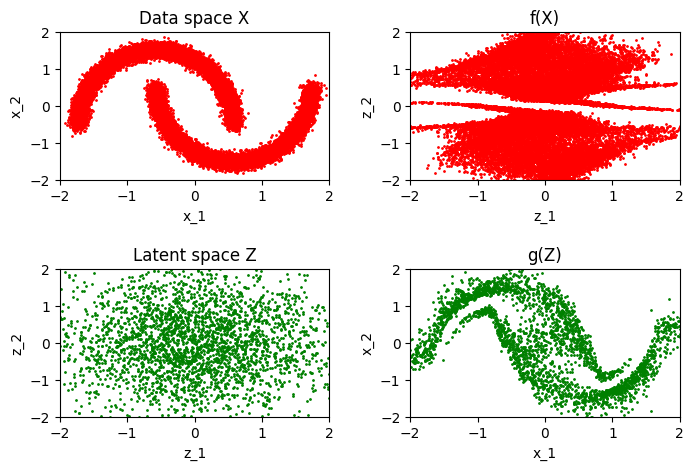

118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 1.6964
Epoch 2/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6980
Epoch 3/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6950
Epoch 4/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6965
Epoch 5/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6983
Epoch 6/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.7035
Epoch 7/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.7051
Epoch 8/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.7016
Epoch 9/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.6956
Epoch 10/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.7113
Epoch 11/60
116/118 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7098
Saved to ./output/generated_img_010.png


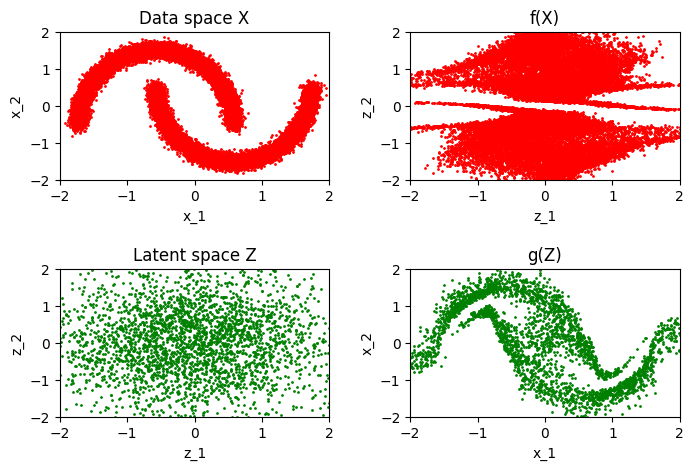

118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.7043
Epoch 12/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6971
Epoch 13/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6941
Epoch 14/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.7053
Epoch 15/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6976
Epoch 16/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6980
Epoch 17/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6983
Epoch 18/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6984
Epoch 19/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6981
Epoch 20/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6991
Epoch 21/60
115/118 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7095
Saved to ./output/generated_img_020.png


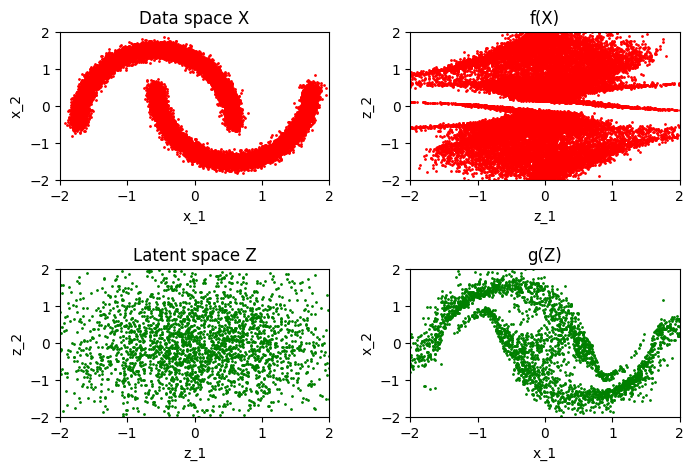

118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.6984
Epoch 22/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.6948
Epoch 23/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.7001
Epoch 24/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.6949
Epoch 25/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6992
Epoch 26/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.6936
Epoch 27/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.7056
Epoch 28/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6978
Epoch 29/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.6930
Epoch 30/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6967
Epoch 31/60
115/118 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6969
Saved to ./output/generated_img_030.png


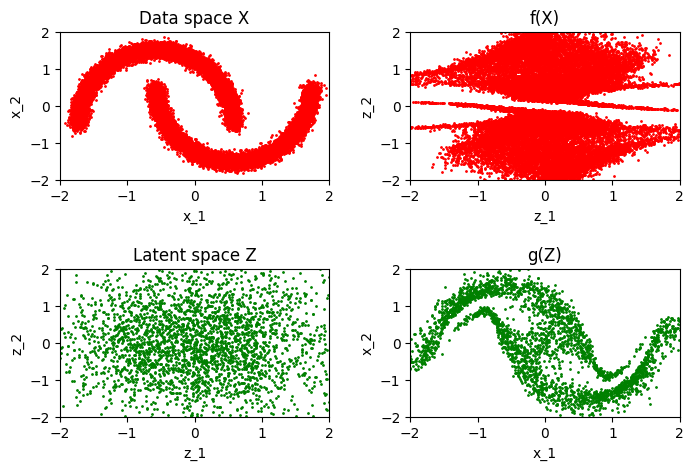

118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.6998
Epoch 32/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.7016
Epoch 33/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6965
Epoch 34/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.7009
Epoch 35/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.6986
Epoch 36/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.7062
Epoch 37/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6954
Epoch 38/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.7004
Epoch 39/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.6997
Epoch 40/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.6998
Epoch 41/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6978
Saved to ./output/generated_img_040.png


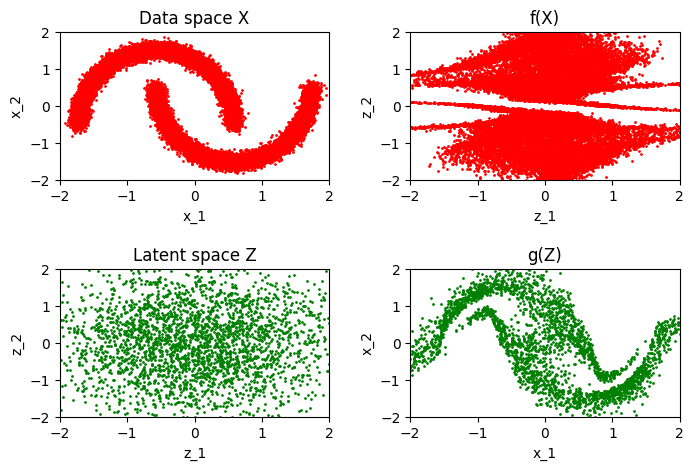

118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.6982
Epoch 42/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.7053
Epoch 43/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6978
Epoch 44/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.6984
Epoch 45/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6986
Epoch 46/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.7227
Epoch 47/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.7054
Epoch 48/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.6985
Epoch 49/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.7269
Epoch 50/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.6999
Epoch 51/60
113/118 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6961
Saved to ./output/generated_img_050.png


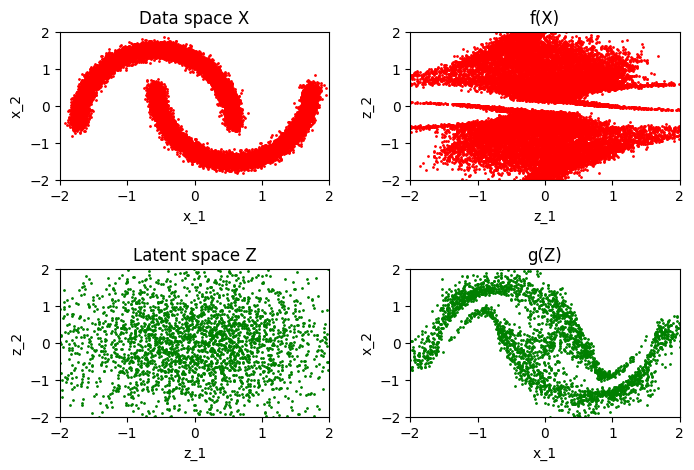

118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.6957
Epoch 52/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6991
Epoch 53/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.6939
Epoch 54/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.6999
Epoch 55/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.7057
Epoch 56/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6955
Epoch 57/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6964
Epoch 58/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6987
Epoch 59/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.6981
Epoch 60/60
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.7017


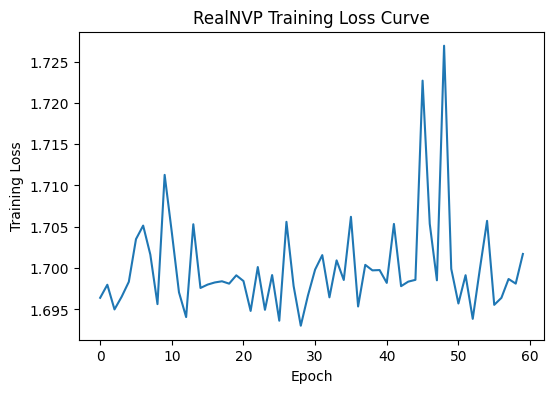

In [57]:
history = model.fit(
    normalized_data,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[tensorboard_callback, img_generator_callback],
)

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("RealNVP Training Loss Curve")
plt.savefig("loss_curve.png", dpi=200)
plt.show()


## 4. Generate images <a name="generate"></a>

In [ ]:
x, z, samples = img_generator_callback.generate()

In [ ]:
img_generator_callback.display(x, z, samples)